# Belarus Car Price Prediction  

## 1. Problem Statement 

- The aim of this project is to predict the price of the car in Belarus, by analyzing the car features such as Brand, Year, Engine, Fuel type, Transmission, Mileage, Drive unit, Color, and Segment. The project also aims to find out the set of variables that has most impact on the car price. 

The dataset has been taken from kaggle. It has 56244 Rows and 12 Columns.

<b>Data Dictionary </b>: 

- `Make   -  Machine firm` 
- `Model - Machine model` 
- `price USD  - Price in USD(target variable)`
- `Year - Year of production` 
- `Condition - represents the condition at the sale moment (with mileage, for parts, etc)`
- `Mileage - Mileage in kilometer `
- `Fuel type - type of the fuel (electro, petrol, disel)`
- `Volume(cm3) - volume of the engine in cubic centimeters` 
- `color - color of the car `
- `transmission - type of transmission` 
- `drive unit - drive unit `
- `segment - Segment of the car` 

In [1]:
# Loading requiremnt libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Gathering 

In [2]:
df = pd.read_csv('cars.csv')

In [3]:
df.head()

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


## 3. Data Preprocessing Part 1 

In [4]:
df.shape

(56244, 12)

In [5]:
df.dtypes

make                    object
model                   object
priceUSD                 int64
year                     int64
condition               object
mileage(kilometers)    float64
fuel_type               object
volume(cm3)            float64
color                   object
transmission            object
drive_unit              object
segment                 object
dtype: object

In [6]:
# Droping columns that are not needed for the analysis 
df.drop(columns= ['model','segment'],inplace= True)

In [7]:
# Unique values in the columns 
df.nunique()

make                     96
priceUSD               2970
year                     78
condition                 3
mileage(kilometers)    8400
fuel_type                 3
volume(cm3)             458
color                    13
transmission              2
drive_unit                4
dtype: int64

In [8]:
# Unique car make 
df['make'].unique()

array(['mazda', 'mg', 'renault', 'gaz', 'aro', 'rover', 'uaz',
       'alfa-romeo', 'audi', 'oldsmobile', 'saab', 'peugeot', 'chrysler',
       'wartburg', 'moskvich', 'volvo', 'fiat', 'roewe', 'porsche', 'zaz',
       'luaz', 'dacia', 'lada-vaz', 'izh', 'raf', 'bogdan', 'bmw',
       'nissan', 'mercedes-benz', 'mitsubishi', 'toyota', 'chery', 'gmc',
       'hyundai', 'honda', 'ssangyong', 'suzuki', 'opel', 'seat',
       'volkswagen', 'daihatsu', 'chevrolet', 'geely', 'saturn', 'kia',
       'lincoln', 'eksklyuziv', 'citroen', 'dong-feng', 'pontiac', 'ford',
       'subaru', 'bentley', 'faw', 'cadillac', 'lifan', 'plymouth',
       'hafei', 'shanghai-maple', 'mini', 'jeep', 'skoda', 'mercury',
       'changan', 'lexus', 'isuzu', 'aston-martin', 'lancia',
       'great-wall', 'land-rover', 'jaguar', 'buick', 'daewoo', 'vortex',
       'infiniti', 'byd', 'smart', 'maserati', 'haval', 'acura', 'scion',
       'tata', 'datsun', 'tesla', 'mclaren', 'ravon', 'trabant', 'proton',
       'fso

Since there are you so many car make, and it is difficult to analyze them individually, so i will group them into categories: Luxury European, Mainstream European, Russina/Eastern European, Asian, American, Speciality, and other. The grouping is based on the car make and the country of origin.

In [9]:
# categorizing the car make 
def car_make(make):
    if make in ['mazda','mg','rover','alfa-romeo','audi','peugeot','chrysler','bmw','aston-martin','jaguar','land-rover']:
        return 'Luxury European'
    elif make in ['renault','decian','citroen','volvo','fiat','opel','seat','volkswagen','citroen','skoda','mini','smart']:
        return 'Mainstream European'
    elif make in ['gaz', 'aro', 'lada-vaz', 'izh', 'raf', 'bogdan', 'moskvich', 'uaz', 'luaz', 'wartburg', 'trabant', 'proton', 'fso', 'jac', 'iran-khodro', 'zotye', 'tagaz', 'saipa', 'brilliance']:
        return 'Russian/Eastern European'
    elif make in ['toyota', 'nissan','asia', 'mitsubishi', 'chery', 'hyundai', 'honda', 'ssangyong', 'suzuki', 'daihatsu', 'kia', 'changan', 'lexus', 'isuzu', 'great-wall', 'daewoo', 'vortex', 'infiniti', 'byd', 'geely', 'haval', 'acura', 'scion', 'tata', 'datsun', 'ravon', 'proton', 'jac']:
        return 'Asian'
    elif make in ['oldsmobile', 'gmc', 'chrysler', 'plymouth', 'ford', 'cadillac', 'jeep', 'mercury', 'lincoln', 'buick', 'saturn', 'pontiac', 'chevrolet']:
        return 'American'
    elif make in ['porsche','bentley', 'maserati', 'tesla', 'mclaren']:
        return 'Specialty'
    else:
        return 'Other'

In [10]:
df['make_segment'] = df['make'].apply(car_make)

In [11]:
df.columns

Index(['make', 'priceUSD', 'year', 'condition', 'mileage(kilometers)',
       'fuel_type', 'volume(cm3)', 'color', 'transmission', 'drive_unit',
       'make_segment'],
      dtype='object')

In [12]:
# Descriptive Statistics 
df.describe()

,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.000000,56244.000000,5.624400e+04,56197.000000
mean,7415.456440,2003.454840,2.443956e+05,2104.860615
std,8316.959261,8.144247,3.210307e+05,959.201633
min,48.000000,1910.000000,0.000000e+00,500.000000
25%,2350.000000,1998.000000,1.370000e+05,1600.000000
50%,5350.000000,2004.000000,2.285000e+05,1996.000000
75%,9807.500000,2010.000000,3.100000e+05,2300.000000
max,235235.000000,2019.000000,9.999999e+06,20000.000000


In [13]:
df.head()

,make,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,make_segment
0,mazda,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,Luxury European
1,mazda,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,Luxury European
2,mazda,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,Luxury European
3,mazda,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,Luxury European
4,mazda,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,Luxury European


### 4. Exploratory Data Analysis 

In the exploratory data analysis, i will analyze the relationship between the target variable and independent variables. I will also analyze the relationship between independent variables. this will help me to understand the data better and to find out the variables that have most impact on the target variable.

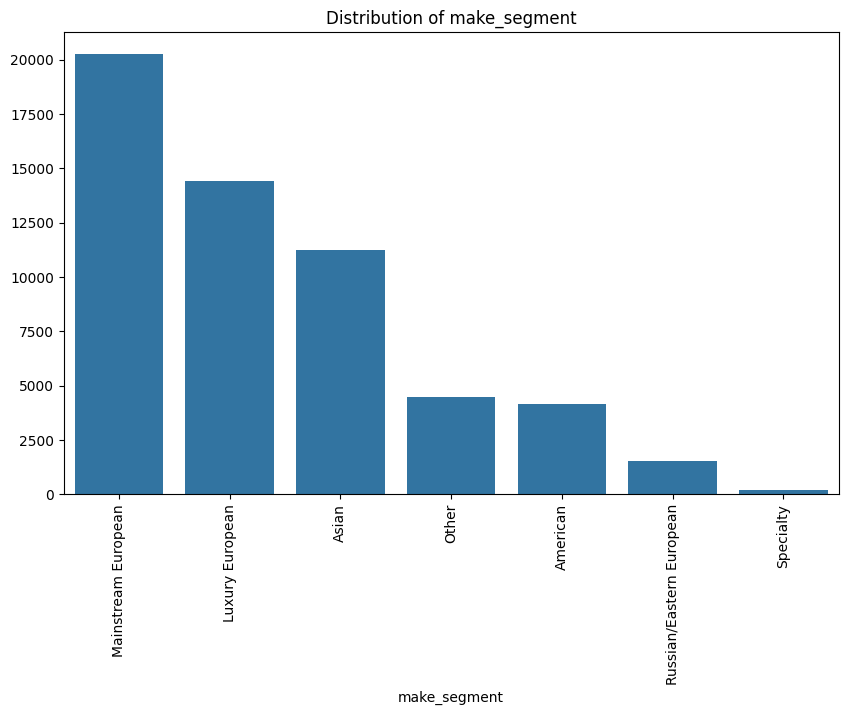

In [14]:
# Get counts of each unique value
data = df['make_segment'].value_counts()

# Plot using the index as x and counts as y
plt.figure(figsize=(10, 6)) # Recommended to set figure size for long labels
sns.barplot(x=data.index, y=data.values)
plt.xticks(rotation=90)
plt.title('Distribution of make_segment')
plt.show()

In the dataset, most of the cars are european (perticulary majority of the Luxury followed by Mainstream and Russian/Eastern European). However the dataset also has american as well asian cars. There are also some speciality cars as Tesla, McLaren, Bentley, etc. The  dataset also has some cars that are not categorized into any of the above categories.

#### Categorical Variable Distribution 

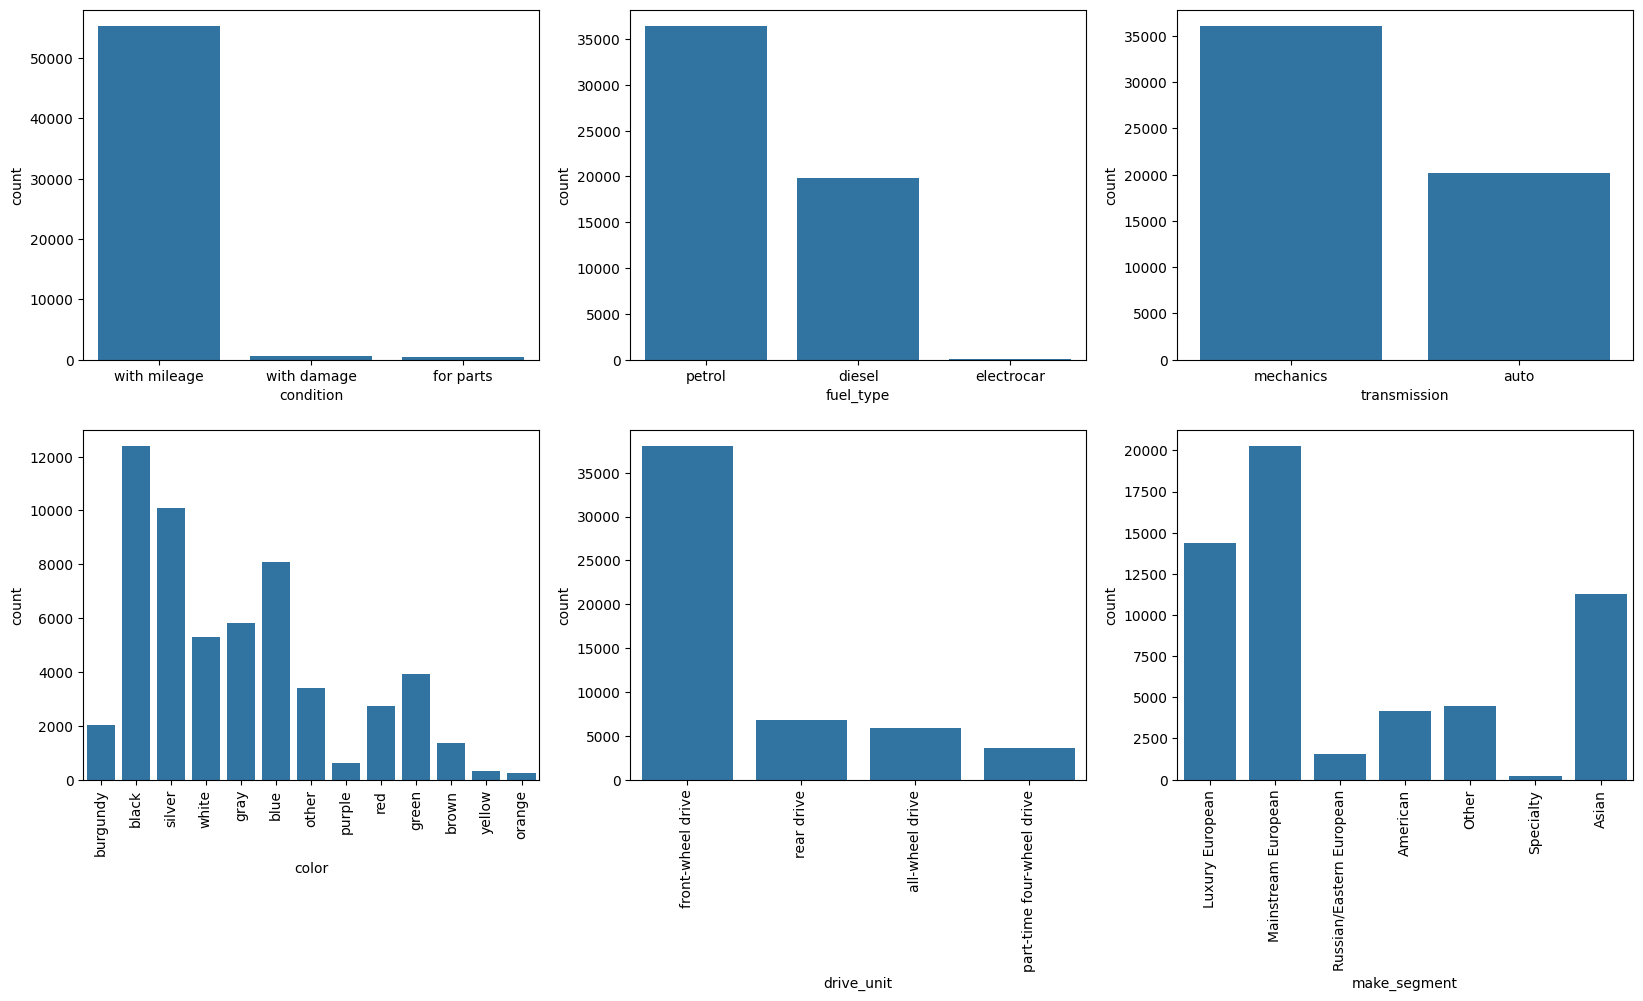

In [15]:
fig, ax = plt.subplots(2,3, figsize = (20,10))
sns.countplot(x = 'condition',data = df, ax = ax[0,0])
sns.countplot(x = 'fuel_type',data = df, ax = ax[0,1])
sns.countplot(x = 'transmission',data = df,ax = ax[0,2])
sns.countplot(x = 'color',data = df, ax = ax[1,0])
ax[1,0].tick_params(axis = 'x',rotation = 90)
sns.countplot(x = 'drive_unit',data = df, ax = ax[1,1])
ax[1,1].tick_params(axis = 'x',rotation = 90)
sns.countplot(x = 'make_segment',data = df, ax = ax[1,2])
ax[1,2].tick_params(axis = 'x',rotation = 90)

From the above graphs, we can get an overview regarding the data across the categorical variables in the data set. The from the above graphs it is clear that majority of the cars are being sold are in working condition, majority of them run on petrol, followed by diesel and hardly any of them runs on electricity. Most of the cars have manual transmission, with front wheel drive, having colors such as balck, silver, blue, white, and grey 

### Continuous Variable Distribution 

<Axes: xlabel='volume(cm3)', ylabel='Count'>

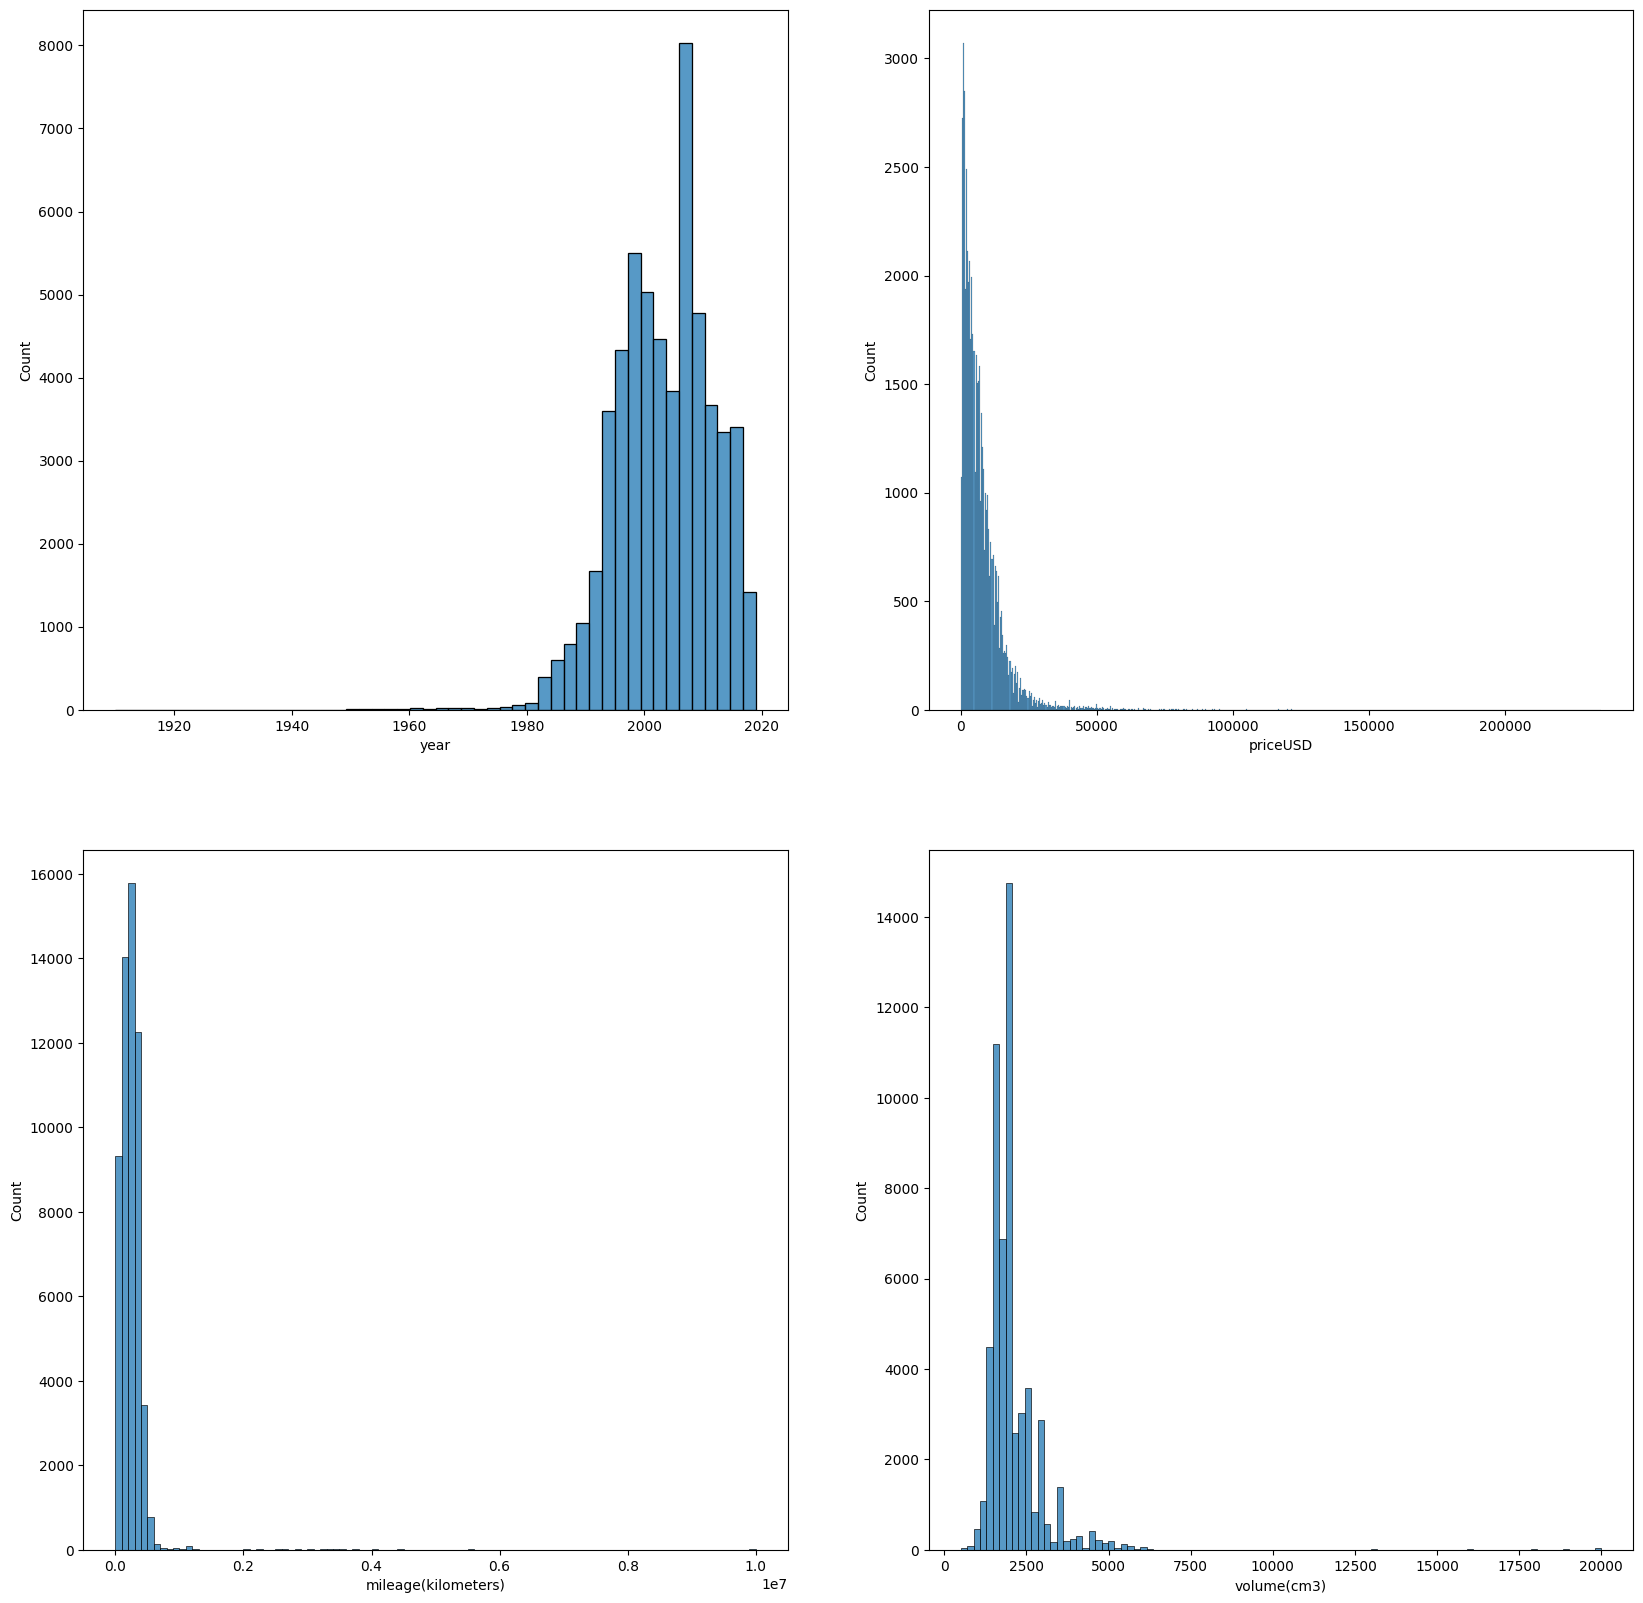

In [16]:
fig, ax = plt.subplots(2,2, figsize = (20,20))
sns.histplot(df['year'],ax = ax[0,0],bins = 50)
sns.histplot(df['priceUSD'],ax = ax[0,1])
sns.histplot(df['mileage(kilometers)'],ax = ax[1,0],bins = 100)
sns.histplot(df['volume(cm3)'],ax = ax[1,1],bins = 100)

The above graphs shows the distribution of the data across continuous variables. Majority of the cars are manufactured between 1990 to 2019, having price less than 50k USD, mileage less than 1 million km, engine volume between 1750 to 2000 cm3.

Since most of the cars are manufactures after 1980, so only consider the cars manufactured after 1980.

In [17]:
df = df[df['year'] > 1980]

### Price and Make 

In [18]:
demodf = df.groupby('make')['priceUSD'].mean().reset_index()
demodf = demodf.sort_values(by = 'priceUSD',ascending = False).head(10)

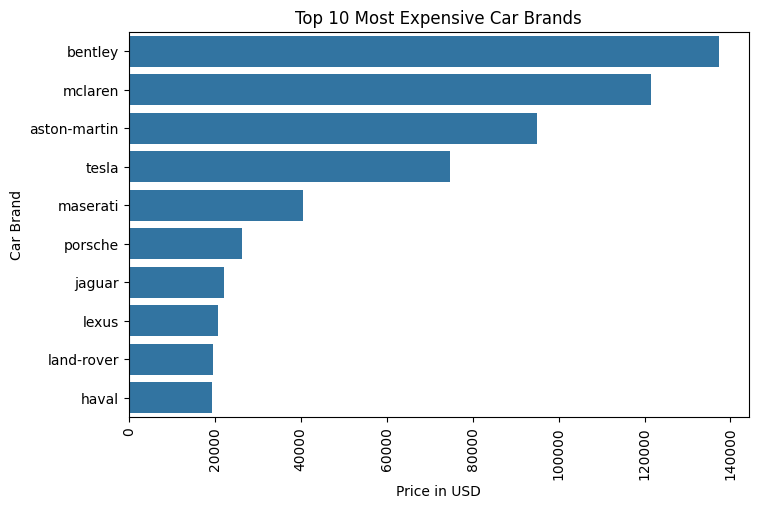

In [19]:
# Bar plot 
plt.figure(figsize = (8,5))
sns.barplot(y = 'make',x = 'priceUSD',data = demodf)
plt.xticks(rotation = 90)
plt.title('Top 10 Most Expensive Car Brands')
plt.ylabel('Car Brand')
plt.xlabel('Price in USD')
plt.show()

This graph shows top 10 most expensive car brands in the data set. The top 5 most expensive car brands are Bentley, Mclaren, aston-martin, Tesla and meserati.

### Price and Condition 

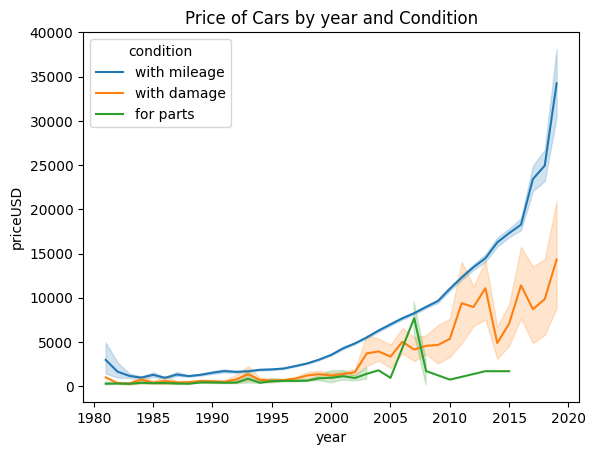

In [20]:
sns.lineplot(x = 'year', y = 'priceUSD', data = df, hue = 'condition')
plt.title('Price of Cars by year and Condition')
plt.show()

This graph shows the relationship between the price and the year of the car along with selling condition of the car. Cars, which are sold in working condition, are more expensive and their price increased with time, having exponential increase between 2015 to 2020. Cars, which were damaged, had a similar price to the cars which were for parts between 1980 to 2000. However, the price of the damaged cars incresed significantly after 2000. Cars, which were sold for parts, tend to have minimal price and their price incresed bery little with time.

The cars running on petrol and diesel have similar mileage, however their prices are quite diffrent. The cars running on petrol trend to have higher price thn the diesel ones. The cars running on electricity trend to have very prices and low mileage. 

In [21]:
# plt.savefig('Price of cars by year and conditions.png') # to save the figure 

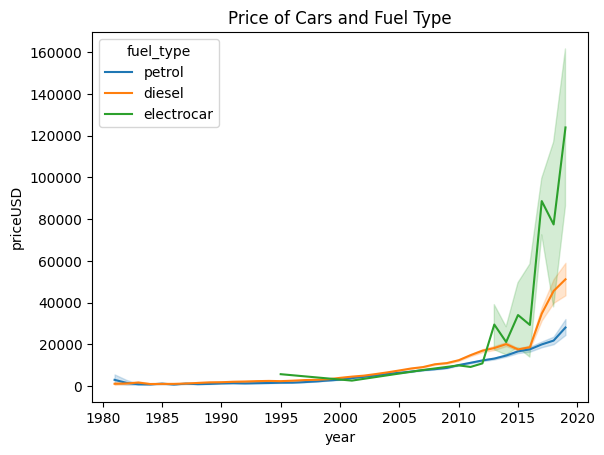

In [22]:
sns.lineplot(x = 'year',y = 'priceUSD',data = df, hue = 'fuel_type')
plt.title('Price of Cars and Fuel Type')
plt.show()

Till 2005, there was no major diffrence in car price of cars running on petrol and diesel. However, after 2015, the price of the cars running on petrol increased significantly, whereas the price of the cars running on diesel increased with a very small margin. The graph also hghlights the introduction of electro cars, which runs on electricity in 1995. However, the price of electro cars increses exponentially after 2015, having the highest car price based on fuel type

### price and Drive Unit 

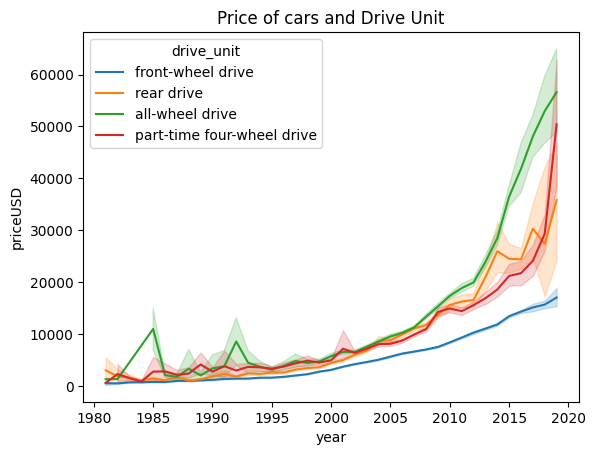

In [23]:
sns.lineplot(x = 'year', y = 'priceUSD', data = df, hue = 'drive_unit')
plt.title('Price of cars and Drive Unit')
plt.show()

Between 1980 to 1995, there was not much diffrence in the price of the cars based on the drive unit. However after 1995, the price of the cars with front wheel drive increased at a slower pace as compared to other drive units. The price of the cars with all wheel drive increased significantly after 2005, having the highest price among all the driver units, followed by part-time four wheel drive units, followed by part-time four wheel drive and rear weel drive.

### Price and Brand Segment 

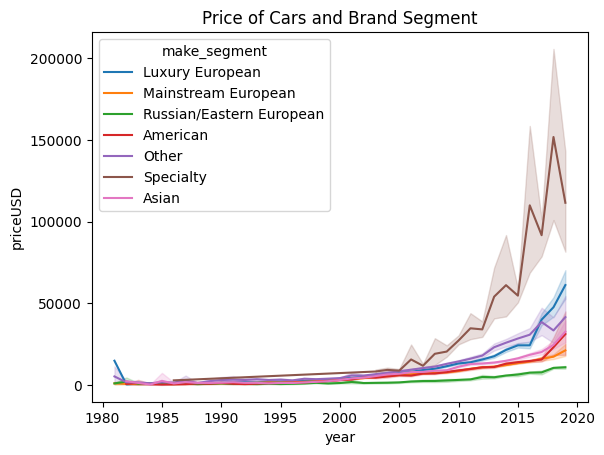

In [24]:
sns.lineplot(x = 'year',y = 'priceUSD',data = df, hue = 'make_segment')
plt.title('Price of Cars and Brand Segment')
plt.show()

This hraph shows the surge in car prices after 2005, where we can seen the price of the specialty car segment increased significantly followed by the luxury european car, American, Asian and Mainstream Europran car segment. The price of the Russian/Eastern European car segment increased at a slower pace as compared to other segment and it is lower among all the segment.

## Data Preprocessing Part 2

In [25]:
# Checking null values 
df.isnull().sum()

make                      0
priceUSD                  0
year                      0
condition                 0
mileage(kilometers)       0
fuel_type                 0
volume(cm3)              47
color                     0
transmission              0
drive_unit             1874
make_segment              0
dtype: int64

Since, the count of null values small in cmparision to that dataset size, i will be dropping the values from the dataset

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
df.dropna(inplace= True)

In [28]:
df.drop(columns= ['make'],inplace= True)

## 5. Feature Engineering 

In [29]:
from sklearn.preprocessing import LabelEncoder

In [30]:
# columns to encode 
cols = ['condition','fuel_type','transmission','color','drive_unit','make_segment']

# Label encoding Object 
le = LabelEncoder()

# Label encoding for each column
for col in cols:
    le.fit(df[col])
    df[col] = le.transform(df[col])
    print(col,df[col].unique())

condition [2 1 0]
fuel_type [1 0]
transmission [1 0]
color [ 3  0 10 11  4  1  7  8  9  5  2 12  6]
drive_unit [1 3 0 2]
make_segment [2 3 5 0 4 6 1]


### Correlation Matrix Heatmap

<Axes: >

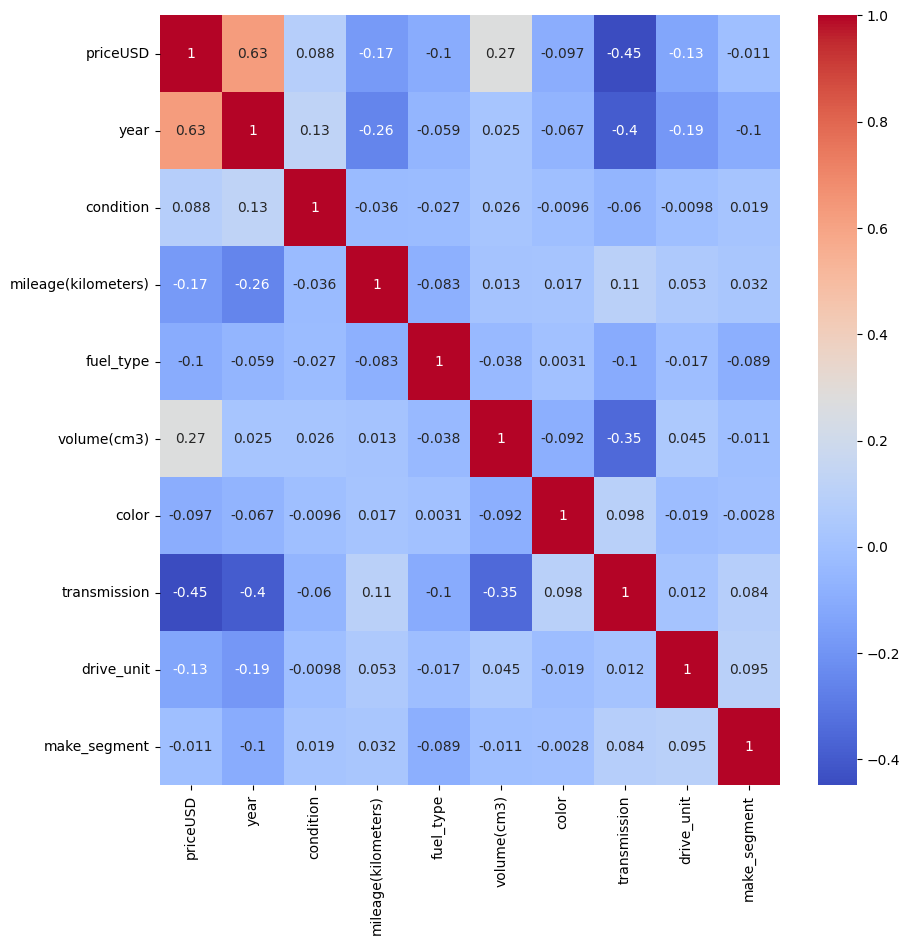

In [31]:
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(),annot=True,cmap = 'coolwarm')

### Outlier Removal 

In [32]:
from scipy import stats

In [33]:
z = np.abs(stats.zscore(df))

threshold = 3

# Columns with outliers 
cols = ['year','mileage(kilometers)','volume(cm3)']

# removing outliers 
df = df[(z < 3).all(axis = 1)]

### Train Test Split 

In [34]:
from sklearn.model_selection import train_test_split

- The target colums will be :  `priceUSD`

In [35]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns = ['priceUSD']),df['priceUSD'],test_size = 0.2,random_state = 42) 

## 6. Model Selection 

### Decision Tree Regressor 

In [36]:
from sklearn.tree import DecisionTreeRegressor

In [37]:
# Decision Tree Regressor Object 
dtr = DecisionTreeRegressor()

### Hypertuning using GridSearchCV

In [38]:
from sklearn.model_selection import GridSearchCV

In [39]:
#parameters for grid search
params = {
    'max_depth': [2,4,6,8],
    'min_samples_split': [2,4,6,8],
    'min_samples_leaf': [1,2,3,4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'random_state': [0,42]
}
# Grid Search Object
grid = GridSearchCV(dtr, param_grid=params, cv=5, verbose=1, n_jobs=-1)

#fitting the grid search
grid.fit(x_train, y_train)

#best parameters
print(grid.best_params_)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'random_state': 42}


In [40]:
#decision tree regressor with best parameters
dtr = DecisionTreeRegressor(max_depth=8, max_features=None, min_samples_leaf=4, min_samples_split=2, random_state=0)

#fitting the model
dtr.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, random_state=0)

In [41]:
#training score 
dtr.score(x_train,y_train)

0.8689180353109258

In [42]:
#predicting the test set 
y_pred = dtr.predict(x_test)

In [43]:
y_pred

array([ 894.87895091, 8830.84555985, 9630.99011532, ..., 5382.31902295,
       1337.64508393, 1337.64508393])

## 7. Model Evaluation 

In [44]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [45]:
print('R2 Score :',r2_score(y_test, y_pred))
print('Mean Squared Error :',mean_squared_error(y_test,y_pred))
print('Mean Absolute Error :',mean_absolute_error(y_test,y_pred))
print('Root Mean Squared Error :',np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.8528623373186828
Mean Squared Error : 4708815.667493125
Mean Absolute Error : 1415.807595447126
Root Mean Squared Error : 2169.980568459802


## 8. Feature Selection 

In [46]:
feat_df = pd.DataFrame({'Feature':x_train.columns,'Importance':dtr.feature_importances_})
feat_df = feat_df.sort_values(by = 'Importance',ascending = False)
feat_df

,Feature,Importance
0,year,0.754360
4,volume(cm3),0.200133
3,fuel_type,0.017348
6,transmission,0.010267
8,make_segment,0.009763
7,drive_unit,0.006993
2,mileage(kilometers),0.000843
5,color,0.000292
1,condition,0.000000


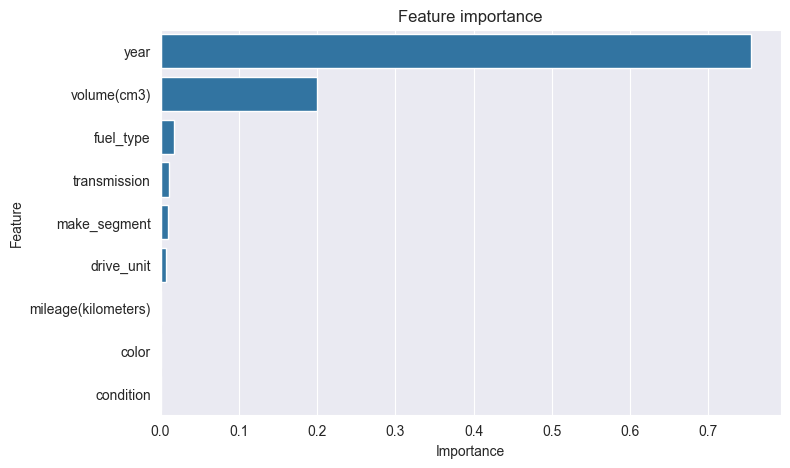

In [47]:
# Bar Plot 
sns.set_style('darkgrid')
plt.figure(figsize = (8,5))
sns.barplot(x = 'Importance',y = 'Feature',data = feat_df)
plt.title('Feature importance')
plt.show()

In [48]:
df.head(2)

,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,make_segment
0,5500,2008,2,162000.0,1,1500.0,3,1,1,2
1,5350,2009,2,120000.0,1,1300.0,0,1,1,2


In [56]:
# year = 2008
# volume(cm3) = 1500.0
# fuel_type = 1 
# transmission = 1
# make_segment = 2
# drive_unit = 1

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (1713159458.py, line 2)

In [66]:
import numpy as np

test_array = np.zeros(len(x_train.columns))

test_array[0] = 2008
test_array[1] = 1500.0
test_array[2] = 1
test_array[3] = 1
test_array[4] = 2
test_array[5] = 1

# reshape
test_array = test_array.reshape(1, -1)

# prediction
prediction = dtr.predict(test_array)

print("Predicted Price:", prediction[0])       # drive_unit

Predicted Price: 3612.043209876543


In [65]:
print(x_train.columns)

Index(['year', 'condition', 'mileage(kilometers)', 'fuel_type', 'volume(cm3)',
       'color', 'transmission', 'drive_unit', 'make_segment'],
      dtype='object')


In [60]:
selected_features = ['year','volume(cm3)','fuel_type','transmission','make_segment','drive_unit']

x = df[selected_features]
y = df['priceUSD']

In [67]:
import pickle

In [69]:
# Save model
with open("car_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [70]:
# Save selected features
with open("features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

In [71]:
print("Model and features saved successfully.")

Model and features saved successfully.


### Conclusion 



The aim of this project was to predict the price of the car in Belarus, by analyzing the car features such as brand, year, engine, fuel type, transmission, mileage, drive unit, color, and segment. During the exploratory data analysis, it was found that there has been a significant increase in car prices in Belarus after the year 2000. The cars which runs on petrol have automatic transmission have higher price has compared to diesel cars with manual transmission. However, the elctric cars are distinctively expensive than the other cars. The cars with all wheel drive have the highest price among all the drive units. The speciality segment cars have the highest price among all the segments followed by luxury european, american, asian car segments.

The decision tree regressor model was used to predict the car price. The model was able to predict the car price with 85.29% accuracy. The most important features for predicting the car price were found to be year and volume of the engine.